In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import json
import sys
import matplotlib.pyplot
import scipy.linalg

In [2]:
import plotly
import plotly.graph_objs as go

# Introduction to numerical methods

János Török

# Class 4: Linear algebra 3.

## System of linear equations

The general form is:
$$\begin{cases}
a_{11} x_1 + a_{12} x_2 +\dots + a_{1n} x_n = b_1 \\
a_{21} x_1 + a_{22} x_2  + \dots + a_{2n} x_n = b_2 \\ 
\vdots\\
a_{m1} x_1 + a_{m2} x_2 + \dots + a_{mn} x_n = b_m,
\end{cases}$$
where $x_1, x_2,\dots,x_n$ are the unknowns, $a_{11},a_{12},\dots,a_{mn}$ are the coefficients of the system, and $b_1,b_2,\dots,b_m$ are the constant terms.

### In matrix form
$$A\mathbf{x}=\mathbf{b},$$
where
$$A=
\begin{pmatrix}
a_{11} & a_{12} & \cdots & a_{1n} \\
a_{21} & a_{22} & \cdots & a_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
a_{m1} & a_{m2} & \cdots & a_{mn}
\end{pmatrix},\quad
\mathbf{x}=
\begin{pmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{pmatrix},\quad
\mathbf{b}=
\begin{pmatrix}
b_1 \\
b_2 \\
\vdots \\
b_m
\end{pmatrix}.$$

### Gauss elimination

First we create a matrix $(A|b)$. The we try to make the value below the diagonal zero, and the diagonal one. Allowed steps:
* Swapping two rows,
* Multiplying a row by a nonzero number,
* Adding a multiple of one row to another row.

Example:

$$\begin{pmatrix}
1 & 3 & 1 & 9 \\
1 & 1 & -1 & 1 \\
3 & 11 & 5 & 35
\end{pmatrix}\to
\begin{pmatrix}
1 & 3 & 1 & 9 \\
0 & -2 & -2 & -8 \\
0 & 2 & 2 & 8
\end{pmatrix}\to
\begin{pmatrix}
1 & 3 & 1 & 9 \\
0 & -2 & -2 & -8 \\
0 & 0 & 0 & 0
\end{pmatrix}\to
\begin{pmatrix}
1 & 0 & -2 & -3 \\
0 & 1 & 1 & 4 \\
0 & 0 & 0 & 0
\end{pmatrix}$$

The steps:
1. The <b>first</b> row times $-1$ is added to the second row, and the $-3$ times the <b>first</b> row is added to the third row
2. The <b>second</b> row is added to the third row resulting in a row with only zeros, which is a singular case.
3. The <b>second</b> row is multiplied by $-2$ and it is added to the first row multiplied by $-3$. 

### Implementation

In [3]:
A = np.array([[1,3,1],[1,1,-1],[3,11,5]],dtype=float)
b = np.array([9,1,35],dtype=float)

In [4]:
B = np.column_stack((A,b))
print(B)

[[ 1.  3.  1.  9.]
 [ 1.  1. -1.  1.]
 [ 3. 11.  5. 35.]]


In [5]:
def GE_swap(B,i,j):
    tmp = np.copy(B[i])
    B[i] = np.copy(B[j])
    B[j] = tmp

In [6]:
GE_swap(B,1,2)
print(B)
B = np.column_stack((A,b))

[[ 1.  3.  1.  9.]
 [ 3. 11.  5. 35.]
 [ 1.  1. -1.  1.]]


In [7]:
def GE_multiply(B,i,alpha):
    B[i] = B[i] * alpha

In [8]:
GE_multiply(B,0,0.5)
print(B)
B = np.column_stack((A,b))

[[ 0.5  1.5  0.5  4.5]
 [ 1.   1.  -1.   1. ]
 [ 3.  11.   5.  35. ]]


In [9]:
def GE_add_multiply(B,i,j,alpha):
    B[i] += B[j] * alpha

In [10]:
GE_add_multiply(B,1,0,-1)
print(B)

[[ 1.  3.  1.  9.]
 [ 0. -2. -2. -8.]
 [ 3. 11.  5. 35.]]


### Gauss elimination algorithm
1. Iterate for each column, except for the last ($i$)
2. In column $i$ find an element in rows at or below $i$ which are nonzero, and swap the rows if necessary
3. Clear all elements in column $i$ below $i$
In the end we should end up with a bottom triangle which is zero

In [11]:
#A safe point where we recreate the matrix and start our development
B = np.column_stack((A,b))
#GE_add_multiply(B,0,1,1)
#GE_swap(B,0,2)
print(B)
N = len(B)

[[ 1.  3.  1.  9.]
 [ 1.  1. -1.  1.]
 [ 3. 11.  5. 35.]]


In [12]:
#column i from row i
i = 0
B[i:,i] 

array([1., 1., 3.])

In [13]:
np.where(B[i:,i] > 0)[0]

array([0, 1, 2])

In [14]:
#Check the topmost row where there are nonzero elements, and give an error message if there aren't any
if len(np.where(B[i:,i] > 0)[0]) == 0:
    print("Singular matrix")
else:
    j = np.where(B[i:,i] > 0)[0].min()
    print(j)

0


In [15]:
#if the nonzero is in an other row, swap the two
if i != j:
    GE_swap(B,i,j)
print(B)

[[ 1.  3.  1.  9.]
 [ 1.  1. -1.  1.]
 [ 3. 11.  5. 35.]]


In [16]:
####
#Now the Gauss-elimination
####
#make the killer element 1
GE_multiply(B,i,1.0/B[i,i])
for j in range(i+1,N):
    GE_add_multiply(B,j,i,-B[j,i])
print(B)

[[ 1.  3.  1.  9.]
 [ 0. -2. -2. -8.]
 [ 0.  2.  2.  8.]]


In [17]:
#Solution
# i in reverse order
#left hand side 

## Solution

$$
B = \begin{pmatrix}
1 & 3 & 1 & 9 \\
0 & 1 & 1 & 4 \\
0 & 0 & 1 & 1
\end{pmatrix}
$$
Expanded form:
\begin{align}
x_3 &= 1 \\
x_2 &= 4 - x_3 \\
x_1 &= 9 - 3x_2 - x_3
\end{align}
For an upper-triangular system, the backward-substitution formula is
$$
x_i = b_i - \sum_{j=i+1}^{N} a_{ij} x_j.
$$
If we initialize the solution vector as $\mathbf{x}^{(0)}=(0,0,0)^T$, then the same relation can be used while moving through the indices in reverse order.

In [18]:
def my_GE(A,b):
    B = np.array(np.column_stack((A,b)),dtype=float)
    N = len(B)
    for i in range(N):
        if B[i,i] == 0.0:
            if len(np.where(B[i:,i] > 0)[0]) == 0:
                raise Exception("Singular matrix")
            else:
                j = np.where(B[i:,i] > 0)[0].min()
                GE_swap(B,i,j)
        GE_multiply(B,i,1.0/B[i,i])
        for j in range(i+1,N):
            GE_add_multiply(B,j,i,-B[j,i])
    sol = np.zeros(N,dtype=float)
    for i in reversed(range(N)):
        sol[i] =  B[i,-1] - (np.dot(B[i,:N],sol)).sum()
    return sol

In [21]:
A = np.array([[1,3,1],[1,1,-1],[3,11,5]],dtype=float)
b = np.array([9,1,35],dtype=float)
A = np.array([[1, 3, 1], [1, 1, -1], [3, 10, 5]], dtype=float)
b = np.array([9, 1, 32], dtype=float)
x = my_GE(A, b)
print(x)

[-1.  3.  1.]


In [22]:
A = np.array([[1,3,1],[1,1,-1],[3,10,5]],dtype=float)
b = np.array([9,1,32],dtype=float)
x = my_GE(A,b)
print(x)

[-1.  3.  1.]


## Iterative methods: Gauss-Seidel
Sometimes iterative methods are desirable, especially when the system is ill-conditioned, when the variables have very different scales, or when the matrix comes from a slowly changing dynamical process. Another important use case is sparse matrices, where exploiting the sparsity pattern is straightforward with iterative methods but difficult with Gauss elimination.

Let us express the components of $\mathbf{x}$ from the set of linear equations in an iterative form, assuming all other components are known:
$$A\mathbf{x}=\mathbf{b}$$
In components:
$$
\begin{aligned}
a_{11}x_1+a_{12}x_2+\dots+a_{1n}x_n &= b_1\\
a_{21}x_1+a_{22}x_2+\dots+a_{2n}x_n &= b_2\\
\vdots\qquad &\qquad \vdots\\
a_{n1}x_1+a_{n2}x_2+\dots+a_{nn}x_n &= b_n
\end{aligned}
$$
The different components can be expressed using a superscript for the iteration count:
$$
\begin{aligned}
x_1^{(i+1)} &= \frac{-1}{a_{11}}\left(a_{12}x_2^{(i)}+\dots+a_{1n}x_n^{(i)}-b_1\right),\\
x_2^{(i+1)} &= \frac{-1}{a_{22}}\left(a_{21}x_1^{(i+1)}+a_{23}x_3^{(i)}+\dots+a_{2n}x_n^{(i)}-b_2\right),\\
\vdots\qquad &\qquad \vdots\\
x_n^{(i+1)} &= \frac{-1}{a_{nn}}\left(a_{n1}x_1^{(i+1)}+a_{n2}x_2^{(i+1)}+\dots+a_{n,n-1}x_{n-1}^{(i+1)}-b_n\right).
\end{aligned}
$$
Please note the minus sign in the numerator of the first term on the right-hand side.

This is the Gauss-Seidel method, and it converges faster because we use the already computed values.
$$
\begin{aligned}
x_1^{(i+1)} &= \frac{-1}{a_{11}}\left(a_{12}x_2^{(i)}+\dots+a_{1n}x_n^{(i)}-b_1\right),\\
x_2^{(i+1)} &= \frac{-1}{a_{22}}\left(a_{21}x_1^{(i+1)}+a_{23}x_3^{(i)}+\dots+a_{2n}x_n^{(i)}-b_2\right),\\
\vdots\qquad &\qquad \vdots\\
x_n^{(i+1)} &= \frac{-1}{a_{nn}}\left(a_{n1}x_1^{(i+1)}+a_{n2}x_2^{(i+1)}+\dots+a_{n,n-1}x_{n-1}^{(i+1)}-b_n\right).
\end{aligned}
$$
In summation form:
$$
x_j^{(i+1)} = \frac{-1}{a_{jj}}\left(\sum_{k=1}^{j-1}a_{jk}x_k^{(i+1)} + \sum_{k=j+1}^{n}a_{jk}x_k^{(i)} - b_j\right)
$$

The last but most important thing to mention is that this method converges only if the matrix $A$ is either diagonally dominant, positive definite, or symmetric. Let us first write the algorithm while keeping in mind that all iterative methods need starting values.

In [23]:
#once again work step by step
A = np.array([[3,1,1],[3,10,5],[1,-1,1]],dtype=float)
b = np.array([1,32,-3],dtype=float)
N = len(b)
my_GE(A,b)

array([-1.,  3.,  1.])

In [24]:
#initial values
x0 = np.ones(N,dtype=float)
x = np.copy(x0)

In [25]:
#iteration, here it is very simple
for j in range(N):
    x[j] = -(np.sum(A[j] * x) - A[j,j] * x[j] - b[j]) / A[j,j]
    print(x)

[-0.33333333  1.          1.        ]
[-0.33333333  2.8         1.        ]
[-0.33333333  2.8         0.13333333]


In [26]:
# stopping conditions
prev_x = np.copy(x)
for j in range(N):
    x[j] = -(np.sum(A[j] * x) - A[j,j] * x[j] - b[j]) / A[j,j]
print(np.linalg.norm(x-prev_x))

1.0373232409296727


In [27]:
#Besides A and b we need three parameters, the stopping limit, maximum iteration and the initial condition
def my_GS(A, b, lim = 1e-3, max_iter = 1000, x0 = []):
    #if init is not given we will start from the vector (1,1,...,1)
    N = len(b)
    if len(x0) != N:
        x0 = np.ones(N,dtype=float)
    x = np.copy(x0)
    for i in range(max_iter):
        prev_x = np.copy(x)
        for j in range(N):
            x[j] = -(np.sum(A[j] * x) - A[j,j] * x[j] - b[j]) / A[j,j]
        if np.linalg.norm(x-prev_x) < lim:
            break
    return x,i,np.linalg.norm(x-prev_x)

In [28]:
#once again work step by step
A = np.array([[3,1,1],[3,10,5],[1,-1,1]],dtype=float)
b = np.array([1,32,-3],dtype=float)

x, niter,lim = my_GS(A,b)
print(x)
print(niter,lim)

[-0.99967631  3.00021519  0.9998915 ]
9 0.0007641281018185905


In [29]:
%%timeit
A = np.array([[3,1,1],[3,10,5],[1,-1,1]],dtype=float)
b = np.array([1,32,-3],dtype=float)
my_GE(A,b)

29.7 μs ± 3.25 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [30]:
%%timeit
A = np.array([[3,1,1],[3,10,5],[1,-1,1]],dtype=float)
b = np.array([1,32,-3],dtype=float)
my_GS(A,b)

140 μs ± 2.51 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [31]:
A = np.array([[1,3,1],[1,1,-1],[3,10,5]],dtype=float)
b = np.array([9,1,32],dtype=float)
x, niter,lim  = my_GS(A,b)
print(x)
print(niter,lim)

[ 8.69234435e+191  1.87447450e+192 -4.27048967e+192]
999 inf


c:\Users\nmate\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\linalg\_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


In [32]:
#symmetric matrix
A = np.array([[1,3,1],[1,4,2],[1,2,4]],dtype=float)
b = np.array([9,13,9],dtype=float)
x, niter,lim  = my_GS(A,b)
print(x)
print(niter,lim)

[-0.99705189  2.99939451  0.99956572]
16 0.0003525996154096707


## LU decomposition
The matrix $A$ is decomposed into an $L$ lower triangle and $U$ upper triangle matrix such that $A=LU$. Example:
$$  \begin{pmatrix}
a_{11} & a_{12} & a_{13} \\
a_{21} & a_{22} & a_{23} \\
a_{31} & a_{32} & a_{33}
\end{pmatrix} =
\begin{pmatrix}
l_{11} &         0 & 0         \\
l_{21} & l_{22} & 0         \\
l_{31} & l_{32} & l_{33}
\end{pmatrix}
\begin{pmatrix}
u_{11} & u_{12} & u_{13} \\
     0 & u_{22} & u_{23} \\
     0 &      0 & u_{33}
\end{pmatrix}$$
In particular a common choice is that:
$$L = \begin{pmatrix}
1 &         0 & 0         \\
l_{21} & 1 & 0         \\
l_{31} & l_{32} & 1
\end{pmatrix},$$
in which case the decomposition is unique.

#### Simple solution:

Use Gauss elimination to get $L$, in a form $L\mathbf{x}=\mathbf{x}$:
$$
\begin{pmatrix}
1&0&\dots&0\\
l_{21}&1&\dots&0\\
\vdots&\vdots&\ddots&0\\
l_{n1}&l_{n2}&\dots&1
\end{pmatrix}
\begin{pmatrix}
x_1\\
x_2\\
\vdots\\
x_n
\end{pmatrix}=
\begin{pmatrix}
b_1\\
b_2\\
\vdots\\
b_n
\end{pmatrix}
$$
Such a matrix can be obtained by writing a Gauss elimination algorithm upside down. The $U$ matrix can be obtained by performing the matrix multiplication of $LU$ and going through in a typewriter style:

The first line:
$$
\begin{align}
a_{11}&=1\cdot u_{11}\\
a_{12}&=1\cdot u_{12}\\
\vdots&=\vdots\\
a_{1n}&=1\cdot u_{1n}
\end{align}
$$
So the first line is the same as that of $A$. The second line:
$$
\begin{align}
a_{21}&=l_{21}\cdot u_{11}\\
a_{22}&=l_{21}\cdot u_{12}+l_{22}\cdot u_{22}\\
\vdots&=\vdots\\
a_{2n}&=\sum_j l_{2j}\cdot u_{jn}
\end{align}
$$
We can see that we only use parts of the $U$ matrix which is already known.

The algorithm is not too difficult we could use our Gauss elimination but we will not implement it. The reason is the possibility of singularity during the process requires pivoting elements (changing rows and columns). One has to keep track of that in three matrices, in $L$, in the actually created $U$ and a pivot matrix $P$, which is defined as $PA=UL$. In general the procedure is done in a different order. First the pivot matrix is determined from the maximum values of the $A$ matrix. If only partial pivoting is done, then the one after the other the row with the highest element in the diagonal is swapped to the actual position, in the case of full pivoting also cloumns are swapped. The pivoting procedure is coded in the pivot matrix.

In [33]:
def my_LU_decomposition_with_pivoting(A):
    """
    Perform LU decomposition with partial pivoting of a square matrix A.
    
    The matrix A is decomposed into a lower triangular matrix L, an upper triangular matrix U,
    and a permutation matrix P such that PA = LU.
    
    Parameters:
    A (numpy.ndarray): The square matrix to decompose.
    
    Returns:
    P (numpy.ndarray): The permutation matrix.
    L (numpy.ndarray): The lower triangular matrix.
    U (numpy.ndarray): The upper triangular matrix.
    """
    n = A.shape[0]
    
    # Initialize L as a zero matrix, U as a copy of A, and P as the identity matrix
    L = np.zeros_like(A, dtype=float)
    U = np.copy(A)
    P = np.eye(n)
    
    for i in range(n):
        # Partial pivoting: find the row with the largest element in the current column
        pivot = np.argmax(np.abs(U[i:, i])) + i
        
        # Swap the rows in U, L, and P
        if pivot != i:
            U[[i, pivot]] = U[[pivot, i]]
            P[[i, pivot]] = P[[pivot, i]]
            if i > 0:
                L[[i, pivot], :i] = L[[pivot, i], :i]
        
        # Update L and U matrices
        L[i, i] = 1
        for j in range(i + 1, n):
            L[j, i] = U[j, i] / U[i, i]
            U[j, i:] -= L[j, i] * U[i, i:]
        print("III",i)
        print("PPP",P)
        print("LLL",L)
        print("UUU",U)
        print("###########################")
    return P, L, U
A = np.array([[3, -1, 4], [17, 2, 1], [1, 12, -7]])
print("Matrix A:")
print(A)
P, L, U = my_LU_decomposition_with_pivoting(A.astype(float))


print("\nPermutation matrix P:")
print(P)
print("\nLower triangular matrix L:")
print(L)
print("\nUpper triangular matrix U:")
print(U)

# Verification: P @ A = L @ U should be close to A
print("\nVerification: P @ A =")
print(np.dot(P, A))
print("\nL @ U =")
print(np.dot(L, U))


Matrix A:
[[ 3 -1  4]
 [17  2  1]
 [ 1 12 -7]]
III 0
PPP [[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]
LLL [[1.         0.         0.        ]
 [0.17647059 0.         0.        ]
 [0.05882353 0.         0.        ]]
UUU [[17.          2.          1.        ]
 [ 0.         -1.35294118  3.82352941]
 [ 0.         11.88235294 -7.05882353]]
###########################
III 1
PPP [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
LLL [[ 1.          0.          0.        ]
 [ 0.05882353  1.          0.        ]
 [ 0.17647059 -0.11386139  0.        ]]
UUU [[17.          2.          1.        ]
 [ 0.         11.88235294 -7.05882353]
 [ 0.          0.          3.01980198]]
###########################
III 2
PPP [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
LLL [[ 1.          0.          0.        ]
 [ 0.05882353  1.          0.        ]
 [ 0.17647059 -0.11386139  1.        ]]
UUU [[17.          2.          1.        ]
 [ 0.         11.88235294 -7.05882353]
 [ 0.          0.          3.01980198]]
###########################

Perm

## Matrix inverse
$$\left(A^{-1}\right)^{-1}=A$$
Or
$$A^{-1}A =A\cdot A^{-1} =I,$$
where $I$ is the identity matrix.

First method: Gauss elimination!

Let us define: $e_x=(1,0,0)$, $e_y=(0,1,0)$, $e_z=(0,0,1)$. Let us search for the solution of:

$$A\mathbf{x}_1=e_x.$$

If you think about matrix multiplication, $\mathbf{x}_1$ is the first column of the inverse matrix. So in
$$A\mathbf{x}_2=e_y, \quad \mathrm{and}\quad A\mathbf{x}_3=e_z$$
$\mathbf{x}_2$ and $\mathbf{x}_3$ are the other two columns of the inverse matrix, so.
$$A\cdot \left(\mathbf{x}_1,\mathbf{x}_2,\mathbf{x}_3\right) = \left(e_x,e_y,e_z\right)$$


In [34]:
#copy paste the GE and add the reverse pass
def my_GE_inverse(A):
    B = np.array(np.column_stack((A,np.identity(len(A)))),dtype=float)
    N = len(B)
    print(B)
    for i in range(N):
        if B[i,i] == 0.0:
            if len(np.where(B[i:,i] > 0)[0]) == 0:
                raise Exception("Singular matrix")
            else:
                j = np.where(B[i:,i] > 0)[0].min()
                GE_swap(B,i,j)
        GE_multiply(B,i,1.0/B[i,i])
        for j in range(i+1,N):
            GE_add_multiply(B,j,i,-B[j,i])
    #reverse pass
    for i in reversed(range(N)):
        for j in range(i):
            GE_add_multiply(B,j,i,-B[j,i])
    print(B)
    return B[:,3:]

In [35]:
A = np.array([[1,3,1],[1,1,-1],[3,10,5]],dtype=float)
np.linalg.inv(A)

array([[-7.5,  2.5,  2. ],
       [ 4. , -1. , -1. ],
       [-3.5,  0.5,  1. ]])

In [36]:
A1 = my_GE_inverse(A)

[[ 1.  3.  1.  1.  0.  0.]
 [ 1.  1. -1.  0.  1.  0.]
 [ 3. 10.  5.  0.  0.  1.]]
[[ 1.   0.   0.  -7.5  2.5  2. ]
 [-0.   1.   0.   4.  -1.  -1. ]
 [ 0.   0.   1.  -3.5  0.5  1. ]]


In [37]:
print(A1)

[[-7.5  2.5  2. ]
 [ 4.  -1.  -1. ]
 [-3.5  0.5  1. ]]


### Using definition
$$A^{-1}=\frac{1}{\mathrm{det}(A)}\mathrm{Adj}(A),$$
where
$$\mathrm{Adj}(A)_{ji}=(-1)^{i+j}\mathrm{det}A_{i'\not=i,j'\not=j}$$
TheAdjuate matrix is the transpose of the minors of the original matrix (cofactor matrix) times a sign. The elementh $i,j$ of the cofactor matrix is the determinant of the matrix which is created by removing the column $i$ and row $j$ frm the original matrix. Let us implement it!


In [38]:
def my_minor(A,i,j):
    return A[np.ix_(np.arange(3)!=i,np.arange(3)!=j)]

In [39]:
A = np.arange(9).reshape(3,3)
A

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [40]:
my_minor(A,0,1)

array([[3, 5],
       [6, 8]])

In [41]:
A = np.array([[1,3,1],[1,1,-1],[3,10,5]],dtype=float)
np.linalg.inv(A)

array([[-7.5,  2.5,  2. ],
       [ 4. , -1. , -1. ],
       [-3.5,  0.5,  1. ]])

In [42]:
C = np.zeros_like(A)
for i in range(3):
    for j in range(3):
        C[i,j] = np.linalg.det(my_minor(A,i,j)) * (-1)**(i+j)

In [43]:
C.T/np.linalg.det(A)

array([[-7.5,  2.5,  2. ],
       [ 4. , -1. , -1. ],
       [-3.5,  0.5,  1. ]])

In [44]:
def my_inv(A):
    C = np.zeros_like(A)
    for i in range(3):
        for j in range(3):
            C[i,j] = np.linalg.det(my_minor(A,i,j)) * (-1)**(i+j)
    return C.T / np.linalg.det(A)

In [45]:
my_inv(A)

array([[-7.5,  2.5,  2. ],
       [ 4. , -1. , -1. ],
       [-3.5,  0.5,  1. ]])

## Eigenvalues and eigenvectors
Characteristic vectors and values of a linear transformation:
$$A\mathbf{v}=\lambda\mathbf{v}.$$
These are the vectors unchanged by the linear transformation $A$.

Example:
$$A = \begin{pmatrix}
  2 & 1\\
  1 & 2
\end{pmatrix}.$$

Taking the determinant of $A-\lambda I$, where $I$ is the identity matrix, the characteristic polynomial of $A$ is
$$\det(A - \lambda I) = \begin{vmatrix}
    2 - \lambda & 1 \\
    1           & 2 - \lambda
  \end{vmatrix} = 3 - 4\lambda + \lambda^2.
$$
This gives the characteristic equation for the eigenvalues:
$$
0 = \det(A - \lambda I) = 3 - 4\lambda + \lambda^2.
$$
The eigenvalues are $\lambda_1=1$ and $\lambda_2=3$. The eigenvectors are obtained by solving the system of linear equations
$(A - \lambda_i I)\mathbf{v}_i=0$, where $\mathbf{v}_i$ is the eigenvector corresponding to eigenvalue $\lambda_i$. Since $\det(A - \lambda_i I)=0$, the eigenvectors are determined up to a constant factor. If there are eigenvalues with multiplicity greater than one, we have an eigenspace and eigenvectors can be chosen as any independent set spanning that space.

The two eigenvectors for this example are determined by:
$$
\begin{aligned}
(A-\lambda_1 I)\mathbf{v}_1 &= \begin{pmatrix}
  1 & 1\\
  1 & 1
\end{pmatrix}
\begin{pmatrix}
  v_{11}\\
  v_{12}
\end{pmatrix}
= \begin{pmatrix}
  0\\
  0
\end{pmatrix},\\
(A-\lambda_2 I)\mathbf{v}_2 &= \begin{pmatrix}
  -1 & 1\\
  1 & -1
\end{pmatrix}
\begin{pmatrix}
  v_{21}\\
  v_{22}
\end{pmatrix}
= \begin{pmatrix}
  0\\
  0
\end{pmatrix}.
\end{aligned}
$$
This gives us $\mathbf{v}_1=(1,-1)$ and $\mathbf{v}_2=(1,1)$.

So the solution method used in analytical calculations is:
1. Characteristic polynomial using the determinant
2. Solution of an $n$-th degree polynomial equation
3. Solution of a set of singular linear equations

<small>Source: Wikipedia</small>

## Find the largest eigenvalue
(from <a href="https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter15.02-The-Power-Method.html">https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter15.02-The-Power-Method.html</a>)

In some problems, we only need to find the largest dominant eigenvalue and its corresponding eigenvector. In this case, we can use the power method, an iterative method that converges to the largest eigenvalue. Let us see how the power method works.

Consider an $n\times n$ matrix $A$ that has $n$ linearly independent real eigenvalues $\lambda_1, \lambda_2, \dots, \lambda_n$ and corresponding eigenvectors $v_1, v_2, \dots, v_n$. Since the eigenvalues are scalars, we can rank them so that
$$|\lambda_1| > |\lambda_2| \geq \dots \geq |\lambda_n|,$$
(we only require $|\lambda_1| > |\lambda_2|$; the rest may be equal).

Because the eigenvectors are independent, they form a basis of the space, which means that any vector $x_0$ in the same space can be written as a linear combination:
$$x_0 = c_1 v_1 + c_2 v_2 + \dots + c_n v_n,$$
with $c_1 \ne 0$; otherwise we need to choose another initial vector.

Now multiply both sides by $A$:
$$Ax_0 = c_1 A v_1 + c_2 A v_2 + \dots + c_n A v_n.$$
Since $Av_i = \lambda_i v_i$, we have
$$Ax_0 = c_1\lambda_1 v_1 + c_2\lambda_2 v_2 + \dots + c_n\lambda_n v_n.$$
We can rewrite this as
$$Ax_0 = c_1\lambda_1\left[v_1 + \frac{c_2}{c_1}\frac{\lambda_2}{\lambda_1}v_2 + \dots + \frac{c_n}{c_1}\frac{\lambda_n}{\lambda_1}v_n\right] = c_1\lambda_1 x_1,$$
where $x_1$ is a new vector.

This finishes the first iteration. We can then multiply $A$ by $x_1$ to start the second iteration:
$$Ax_1 = \lambda_1\left[v_1 + \frac{c_2}{c_1}\frac{\lambda_2^2}{\lambda_1^2}v_2 + \dots + \frac{c_n}{c_1}\frac{\lambda_n^2}{\lambda_1^2}v_n\right] = \lambda_1 x_2.$$
Continuing this process, after $k$ iterations we get
$$Ax_{k-1} = \lambda_1\left[v_1 + \frac{c_2}{c_1}\left(\frac{\lambda_2}{\lambda_1}\right)^k v_2 + \dots + \frac{c_n}{c_1}\left(\frac{\lambda_n}{\lambda_1}\right)^k v_n\right] = \lambda_1 x_k.$$
Because $\lambda_1$ is the largest eigenvalue, for all $i>1$ we have $\left|\frac{\lambda_i}{\lambda_1}\right|<1$. Therefore, as $k$ becomes large, the terms involving $\left(\frac{\lambda_i}{\lambda_1}\right)^k$ become negligible, and we approach
$$Ax_{k-1} \approx \lambda_1 v_1.$$
So, for sufficiently large $k$, we obtain the dominant eigenvalue and its corresponding eigenvector. In implementation, we usually normalize the vector after each iteration. This is done by dividing by the largest component or by the norm of the vector, so that the vector has unit length and the scale is absorbed into the eigenvalue estimate.

The basic stopping criteria are:
1. the difference between successive eigenvalue estimates is below a tolerance;
2. the angle between successive eigenvectors is below a threshold; or
3. the norm of the residual vector is sufficiently small.

### The method
Iteration:
$$\mathbf{b}_{k+1} = \frac{A\mathbf{b}_k}{\|A\mathbf{b}_k\|}.$$
Condition:
1. The starting vector $\mathbf{b}_k$ must have a nonzero component in the direction of the eigenvector of the largest eigenvalue $\mathbf{v}_1$.
2. $\lambda_1$ is significantly larger than the second largest eigenvalue $\lambda_2$.

### The method
Iteration:
$$\mathbf{b}_{k+1} = \frac{A\mathbf{b}_k}{\|A\mathbf{b}_k\|}.$$
Condition:
1. The starting vector $\mathbf{b}_k$ must have a nonzero component in the direction of the eigenvector of the largest eigenvalue $\mathbf{v}_1$.
2. $\lambda_1$ is significantly larger than the second largest eigenvalue $\lambda_2$.

### numpy version

In [46]:
A = np.array([[2,1],[1,2]],dtype=float)
l,v = np.linalg.eig(A)
print(l[0],v[:,0])
print(l[1],v[:,1])

(3+0j) [0.70710678+0.j 0.70710678+0.j]
(1+0j) [-0.70710678+0.j  0.70710678+0.j]


### Power method

In [47]:
def one_step(A,v):
    v = np.dot(A,v)
    v /= np.linalg.norm(v)
    return v

In [48]:
A = np.array([[2,1],[1,2]],dtype=float)

In [49]:
b = np.random.random(len(A))-0.5
b

array([0.40618436, 0.35810033])

In [50]:
numiter = 5
bs = np.zeros((numiter,len(b)),dtype=float)
for k in range(numiter):
    b = one_step(A,b)
    bs[k] = b

In [51]:
bs

array([[0.721777  , 0.69212569],
       [0.71203236, 0.70214665],
       [0.70875251, 0.70545721],
       [0.70765579, 0.70655735],
       [0.70728983, 0.70692368]])

In [52]:
nulla = np.zeros_like(bs[:,0])
nulla

array([0., 0., 0., 0., 0.])

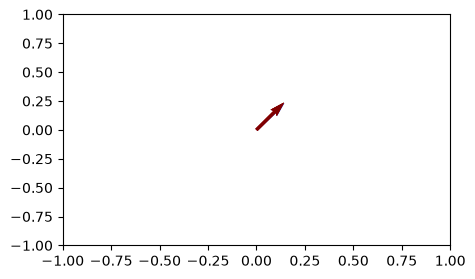

In [53]:
fig, ax = plt.subplots(figsize =(5, 3))
cmap = cm.jet
ax.axis([-1,1,-1,1])
color = np.dot(bs,bs[-1])
color -= color.min()
color /= color.max()
ax.quiver(nulla,nulla,bs[:,0],bs[:,1],scale=10,color=cmap(color));

### Eigen values
Obviously should check for zeros....

In [54]:
l = (np.abs(np.dot(A,bs[-1])).max()/np.abs(bs[-1]).max())
print(l,bs[-1])

2.999482325262967 [0.70728983 0.70692368]


In [55]:
np.dot(A,bs[-1]),bs[-1]*3

(array([2.12150335, 2.1211372 ]), array([2.12186949, 2.12077105]))

### Second largest Eigenvalue and vector
Shift the spectrum such that the largest will be the smallest

This method can also be used to find very precisely one eigenvalue. Take a value $l$ which close but not equal to the searched eigenvalue $\lambda_i$. Shift the spctrum with $l$ then take the inverse matrix. This will make the smallest the biggest and we will get very precisely the deviation from $l$ and the eqigenvalue as well.

In [56]:
B = A - np.diag(np.ones(len(bs[-1]))*l)

In [57]:
np.linalg.eig(A),np.linalg.eig(B)

(EigResult(eigenvalues=array([3.+0.j, 1.+0.j]), eigenvectors=array([[ 0.70710678+0.j, -0.70710678+0.j],
        [ 0.70710678+0.j,  0.70710678+0.j]])),
 EigResult(eigenvalues=array([ 5.17674737e-04+0.j, -1.99948233e+00+0.j]), eigenvectors=array([[ 0.70710678+0.j, -0.70710678+0.j],
        [ 0.70710678+0.j,  0.70710678+0.j]])))

In [58]:
def power_iter(A,numiter = 5):
    b = np.random.random(len(A)) - 0.5
    bs = np.zeros((numiter,len(b)),dtype=float)
    for k in range(numiter):
        b = np.dot(A,b)
        b /= np.linalg.norm(b)
        bs[k] += b
    l = (np.dot(A,bs[-1])/bs[-1]).mean()
    return (l,bs[-1],bs)

In [59]:
power_iter(B)

(np.float64(-1.9994823252629672),
 array([ 0.70710678, -0.70710678]),
 array([[ 0.7058551 , -0.70835625],
        [-0.7071071 ,  0.70710646],
        [ 0.70710678, -0.70710678],
        [-0.70710678,  0.70710678],
        [ 0.70710678, -0.70710678]]))

In [60]:
A = np.array([[2,1],[1,2]],dtype=float)
B = A - np.diag([1,1])

In [61]:
np.linalg.eig(B)

EigResult(eigenvalues=array([2.+0.j, 0.+0.j]), eigenvectors=array([[ 0.70710678+0.j, -0.70710678+0.j],
       [ 0.70710678+0.j,  0.70710678+0.j]]))

### The shifted inverse power method

In [62]:
A = np.array([[2,1],[1,2]],dtype=float)
B = A - np.diag([2.9,2.9])

In [63]:
np.linalg.eig(np.linalg.inv(B))

EigResult(eigenvalues=array([10.        +0.j, -0.52631579+0.j]), eigenvectors=array([[ 0.70710678+0.j, -0.70710678+0.j],
       [ 0.70710678+0.j,  0.70710678+0.j]]))

In [64]:
np.linalg.inv(B)

array([[4.73684211, 5.26315789],
       [5.26315789, 4.73684211]])

In [65]:
power_iter(np.linalg.inv(B))

(np.float64(10.000000000216406),
 array([-0.70710357, -0.70710999]),
 array([[-0.24904155, -0.9684928 ],
        [-0.72874576, -0.68478435],
        [-0.7059484 , -0.70826327],
        [-0.7071677 , -0.70704586],
        [-0.70710357, -0.70710999]]))

So the eigenvalue is $2.9+1/10=3$ and the corresponding eigenvector is $(1/\sqrt{2},1/\sqrt{2})$.

### Multiple largest values
We have a eigenplane and any vector on eigenplane is fine

In [66]:
np.linalg.eig(np.array([[1,0],[0,1]]))

EigResult(eigenvalues=array([1.+0.j, 1.+0.j]), eigenvectors=array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]]))

In [67]:
power_iter(np.diag([1,1]))

(np.float64(1.0),
 array([ 0.59236657, -0.80566857]),
 array([[ 0.59236657, -0.80566857],
        [ 0.59236657, -0.80566857],
        [ 0.59236657, -0.80566857],
        [ 0.59236657, -0.80566857],
        [ 0.59236657, -0.80566857]]))

## Complex eigenvalues
It should not work unless $\mathbf{b}$ ha the correct complex phase, moreover for real matrices there are always two eigenvalues which are complex conjugate of each other which means that their aboslute value is the same.

In [68]:
a = np.pi/6
A = np.array([[np.cos(a),-np.sin(a)],[np.sin(a),np.cos(a)]])

In [69]:
np.linalg.eig(A)

EigResult(eigenvalues=array([0.8660254+0.5j, 0.8660254-0.5j]), eigenvectors=array([[0.70710678+0.j        , 0.70710678-0.j        ],
       [0.        -0.70710678j, 0.        +0.70710678j]]))

In [70]:
power_iter(A)

(np.float64(0.5193560530136268),
 array([ 0.88594091, -0.46379812]),
 array([[-0.84463141, -0.53534827],
        [-0.46379812, -0.88594091],
        [ 0.0413095 , -0.9991464 ],
        [ 0.53534827, -0.84463141],
        [ 0.88594091, -0.46379812]]))

In [71]:
def power_iter_complex(A,numiter = 5):
    b = np.random.random(len(A)) + 1.j * np.random.random(len(A))
    bs = np.zeros((numiter,len(b)),dtype=complex)
    for k in range(numiter):
        b = np.dot(A,b)
        b /= np.linalg.norm(b)
        bs[k] += b
    l = (np.dot(A,bs[-1])/bs[-1]).mean()
    return (l,bs[-1],bs)

In [72]:
power_iter_complex(A,numiter=10)

(np.complex128(0.5910783378789717-0.18687704362013238j),
 array([ 0.42347886+0.75622172j, -0.37127226-0.33309351j]),
 array([[ 0.37127226+0.33309351j,  0.42347886+0.75622172j],
        [ 0.10979178-0.08964342j,  0.55237958+0.82145397j],
        [-0.18110732-0.48836046j,  0.53327064+0.6665783j ],
        [-0.42347886-0.75622172j,  0.37127226+0.33309351j],
        [-0.55237958-0.82145397j,  0.10979178-0.08964342j],
        [-0.53327064-0.6665783j , -0.18110732-0.48836046j],
        [-0.37127226-0.33309351j, -0.42347886-0.75622172j],
        [-0.10979178+0.08964342j, -0.55237958-0.82145397j],
        [ 0.18110732+0.48836046j, -0.53327064-0.6665783j ],
        [ 0.42347886+0.75622172j, -0.37127226-0.33309351j]]))

In [73]:
C = np.array([[0,-1.j],[-1.j,1.j]])
np.linalg.eig(C)

EigResult(eigenvalues=array([0.-0.61803399j, 0.+1.61803399j]), eigenvectors=array([[ 0.85065081+0.00000000e+00j, -0.52573111-2.77555756e-17j],
       [ 0.52573111-0.00000000e+00j,  0.85065081+0.00000000e+00j]]))

In [74]:
power_iter_complex(C,numiter=10)

(np.complex128(4.365401221971341e-05+1.6182326348831486j),
 array([ 0.16416225+0.49928463j, -0.2657961 -0.8081572j ]),
 array([[ 0.87471552-0.42680252j, -0.22934837-0.0105682j ],
        [-0.00879183+0.19079794j, -0.34627084-0.91848536j],
        [-0.60459121+0.22793211j,  0.73018358-0.2221449j ],
        [-0.13865898-0.45576787j,  0.28093023+0.83314317j],
        [ 0.51566355-0.17387825j, -0.79775537+0.25969949j],
        [ 0.16053738+0.49314521j, -0.268023  -0.81191085j],
        [-0.50180413+0.16565248j,  0.80659413-0.26487313j],
        [-0.16370134-0.49850485j,  0.26608067+0.80863827j],
        [ 0.49976627-0.16444701j, -0.80785942+0.26562007j],
        [ 0.16416225+0.49928463j, -0.2657961 -0.8081572j ]]))

## Summary
There are other iterative methods to obtain the eigenvalues e.g. QR method which recovers all eigenvalues directly from which the eigenvectors can be obtaind using linear algebra. Nevertheless the power method is still used, especially for huge sparse matrices (Page rank of google is a good example)

## Change of basis

Basis: $\mathbf{e}_1,\mathbf{e}_2,\dots \mathbf{e}_n$, here the vectors $\mathbf{e}_i$ are linearly independent.

New basis: $\mathbf{f}_1,\mathbf{f}_2,\dots \mathbf{f}_n$, where the vectors $\mathbf{f}_i$ are linearly independent and we know the coordinates of these vectors in the base $\{\mathbf{e}_i\}$:
$$
\begin{align}
\mathbf{f_1} &= \sum_{i=1}^n f_{1i} \mathbf{e_i}\\
\mathbf{f_2} &= \sum_{i=1}^n f_{2i} \mathbf{e_i}\\
\vdots &=\vdots\\
\mathbf{f_n} &= \sum_{i=1}^n f_{ni} \mathbf{e_i}
\end{align}
$$

When we talk about a vector or matrix, generally we use its coordinates, in a give basis. The question is if a vector $\mathbf{b}$ or matrix $A$ is given in basis $\{\mathbf{e}_i\}$ then what are its coordinates in the new basis?

Let us have a vector $\mathbf{b}$ in basis $\{\mathbf{e}_i\}$, then we can use the coefficients $b_i$ which unambiogously determine $\mathbf{b}$.
$$\mathbf{b}=\sum_{i=1}^n b_i\mathbf{e}_i$$
and
$$b_i=\mathbf{e_i}\mathbf{b}.$$
The question is what are the $b_i^{(f)}$ coefficients in the bases $\{\mathbf{f}_i\}$? We are looking for $P$ such that:
$$b_j^{(f)}=\sum_i P_{ij} b_i^{(e)}$$

It is easy to see that if $\mathbf{b}\equiv \mathbf{e}_1$, then the first column of $P_{ij}$ is $\mathbf{f}_1$, and so on, so the columns of $P_{ij}$are made of the vectors $\{\mathbf{f}_i\}$.
$$P=\begin{pmatrix}
\begin{pmatrix}
(f_1)_1\\
(f_1)_2\\
\vdots\\
(f_1)_n
\end{pmatrix}
\begin{pmatrix}
(f_2)_1\\
(f_2)_2\\
\vdots\\
(f_2)_n
\end{pmatrix}
\dots
\begin{pmatrix}
(f_n)_1\\
(f_n)_2\\
\vdots\\
(f_n)_n
\end{pmatrix}
\end{pmatrix}
$$

### Example
We use the usual basis for $\{\mathbf{e_i}\}$: $\mathbf{e}_1=(1,0)$ and $\mathbf{e}_2=(0,1)$.
$$
\begin{align}
\mathbf{f}_1 &= (3,1)\\
\mathbf{f}_1 &= (-2,1)
\end{align}$$

In [75]:
P = np.array([[3,-2],[1,1]])
P

array([[ 3, -2],
       [ 1,  1]])

We transform the vector $(0,1)_f$ back to the system of $\{\mathbf{e}_i\}$:

In [76]:
np.dot(P,[0,1])

array([-2,  1])

In [77]:
A = np.array([[2,1],[1,2]])

In [78]:
np.linalg.eig(A)

EigResult(eigenvalues=array([3.+0.j, 1.+0.j]), eigenvectors=array([[ 0.70710678+0.j, -0.70710678+0.j],
       [ 0.70710678+0.j,  0.70710678+0.j]]))

The matrix $A$ in basis $\{\mathbf{f}_i\}$:

In [79]:
B = np.linalg.inv(P).dot(np.dot(A,P))
B

array([[ 3.4, -0.6],
       [ 1.6,  0.6]])

In [80]:
l,v = np.linalg.eig(B)
l,v

(array([3.+0.j, 1.+0.j]),
 array([[0.83205029+0.j, 0.24253563+0.j],
        [0.5547002 +0.j, 0.9701425 +0.j]]))

Eigenvectors of $B$ transformed back to system of $\{\mathbf{e}_i\}$.

In [81]:
np.dot(P,v[:,0]),np.dot(P,v[:,1])

(array([1.38675049+0.j, 1.38675049+0.j]),
 array([-1.21267813+0.j,  1.21267813+0.j]))